Random Forrest Model - Decision Trees and K- Nearest Neighbors 

Modeling rows: 2,966
Using device: cpu

Training...
  Epoch  10/100 | Train Loss: 3.2253 | Val Loss: 2.5345
  Epoch  20/100 | Train Loss: 3.0000 | Val Loss: 2.4971
  Epoch  30/100 | Train Loss: 3.0085 | Val Loss: 2.4838
  Epoch  40/100 | Train Loss: 2.9772 | Val Loss: 2.4655
  Epoch  50/100 | Train Loss: 2.9754 | Val Loss: 2.4667
  Epoch  60/100 | Train Loss: 2.9365 | Val Loss: 2.4680
  Epoch  70/100 | Train Loss: 2.8587 | Val Loss: 2.4654
  Epoch  80/100 | Train Loss: 2.9547 | Val Loss: 2.4679
  Epoch  90/100 | Train Loss: 2.9724 | Val Loss: 2.4652
  Epoch 100/100 | Train Loss: 2.9255 | Val Loss: 2.4680

RMSE: 9226.08 acres
R²  : 0.136 (on log scale)


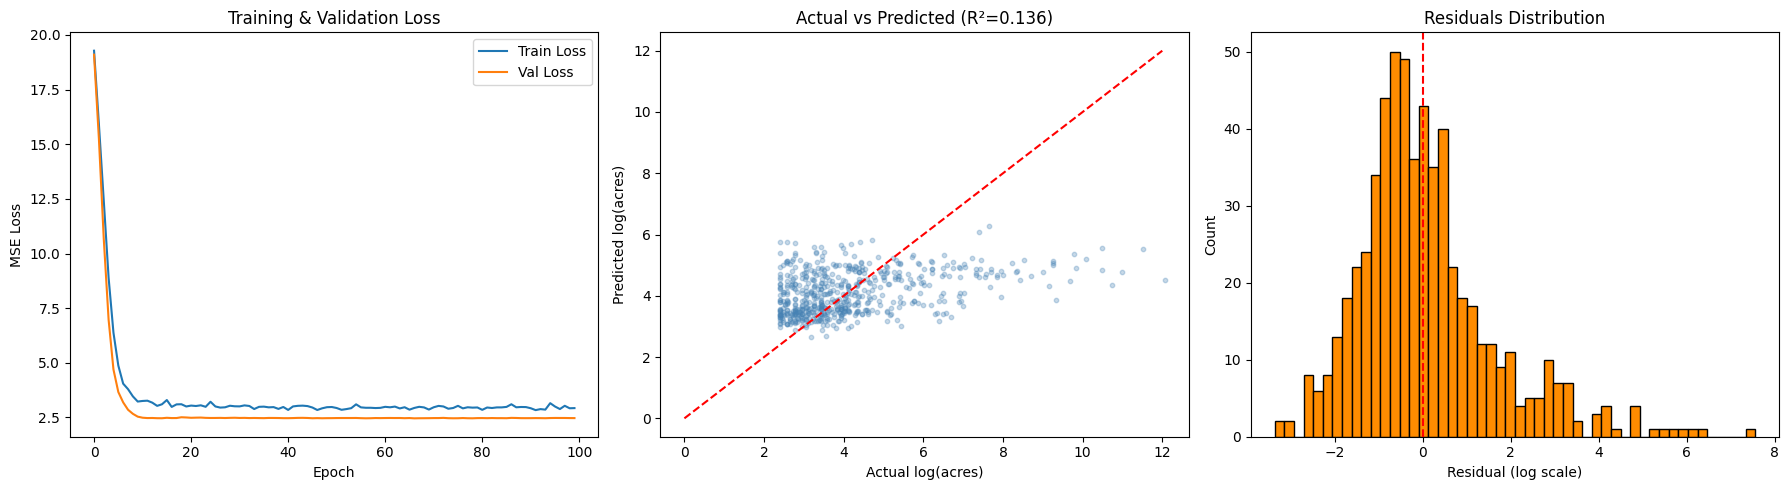


 Saved neural_network_results.png!


In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ── Load data ─────────────────────────────────────────────────────────
df = pd.read_csv('oregon_fires_weather_merged.csv', parse_dates=['report_date'])

features = ['TEMP','MAX','MIN','TEMP_RANGE','DEWP','VPD_PROXY',
            'WDSP','MXSPD','PRCP','PRCP_30DAY','MONTH','DOY','FIRE_SEASON']

df_model = df[features + ['total_acres']].dropna()
df_model = df_model[df_model['total_acres'] >= 10].copy()  # focus on non-trivial fires
print(f"Modeling rows: {len(df_model):,}")

X = df_model[features].values
y = np.log1p(df_model['total_acres'].values)  # log transform

# ── Scale features ────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Train/test split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ── Convert to PyTorch tensors ────────────────────────────────────────
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=256, shuffle=True)

# ════════════════════════════════════════════════════════════════════
# Define Neural Network
# ════════════════════════════════════════════════════════════════════
class FireSizeNet(nn.Module):
    def __init__(self, input_dim):
        super(FireSizeNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

# ── Initialize model ──────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model     = FireSizeNet(input_dim=len(features)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# ════════════════════════════════════════════════════════════════════
# Training Loop
# ════════════════════════════════════════════════════════════════════
epochs     = 100
train_losses = []
val_losses   = []

print("\nTraining...")
for epoch in range(epochs):
    # ── Train ─────────────────────────────────────────────────────
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    # ── Validate ──────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_t.to(device))
        val_loss = criterion(val_pred, y_test_t.to(device)).item()

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# ════════════════════════════════════════════════════════════════════
# Evaluate
# ════════════════════════════════════════════════════════════════════
model.eval()
with torch.no_grad():
    y_pred_log = model(X_test_t.to(device)).cpu().numpy().flatten()

y_pred_acres = np.expm1(y_pred_log)
y_test_acres = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_acres, y_pred_acres))
r2   = r2_score(y_test, y_pred_log)
print(f"\nRMSE: {rmse:.2f} acres")
print(f"R²  : {r2:.3f} (on log scale)")

# ════════════════════════════════════════════════════════════════════
# Plots
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses,   label='Val Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# Actual vs predicted
axes[1].scatter(y_test, y_pred_log, alpha=0.3, s=10, color='steelblue')
axes[1].plot([0, 12], [0, 12], 'r--')
axes[1].set_xlabel('Actual log(acres)')
axes[1].set_ylabel('Predicted log(acres)')
axes[1].set_title(f'Actual vs Predicted (R²={r2:.3f})')

# Residuals
residuals = y_test - y_pred_log
axes[2].hist(residuals, bins=50, color='darkorange', edgecolor='black')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_title('Residuals Distribution')
axes[2].set_xlabel('Residual (log scale)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('neural_network_results.png', dpi=150)
plt.show()
print("\n Saved neural_network_results.png!")

Modeling rows: 2,966 | Features: 16
Training with early stopping...
  Epoch  10 | Train: 0.8600 | Val: 0.7441 | Best: 0.7248
  Epoch  20 | Train: 0.8096 | Val: 0.7341 | Best: 0.7248
  Early stopping at epoch 22

RMSE : 9229.71 acres
R²   : 0.104 (on log scale)


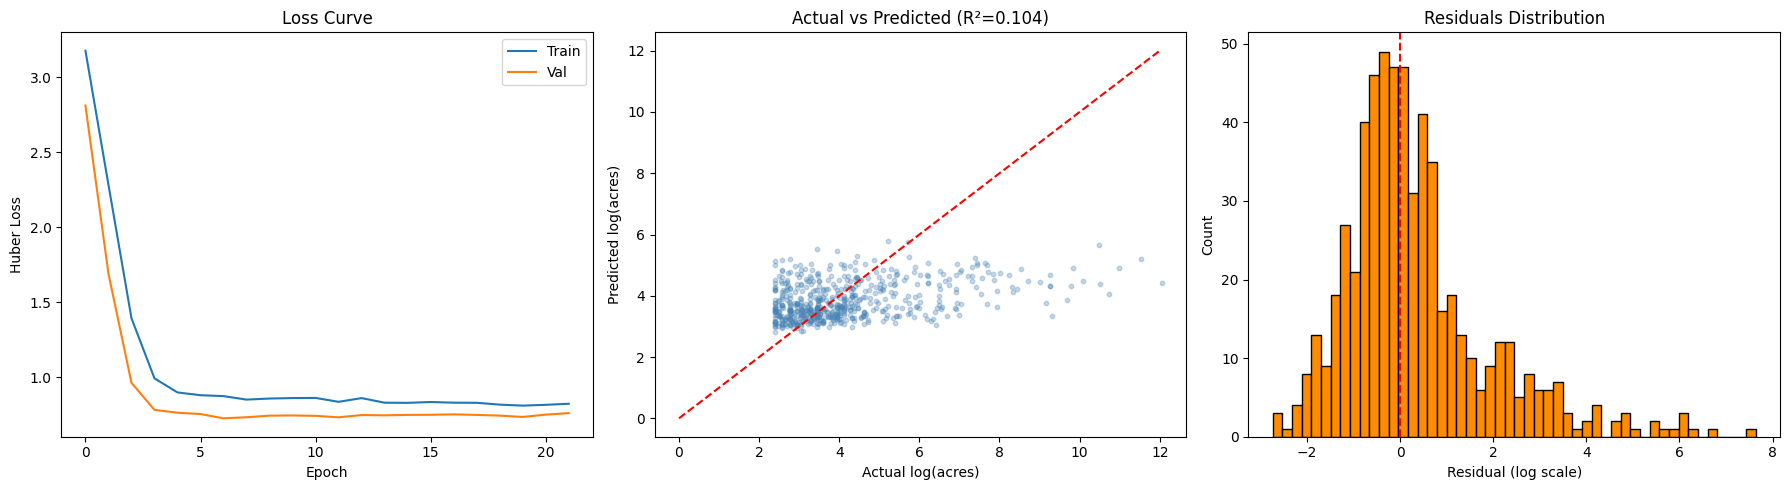


🎉 Saved neural_network_results.png!


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ── Load data ─────────────────────────────────────────────────────────
df = pd.read_csv('oregon_fires_weather_merged.csv', parse_dates=['report_date'])

features = ['TEMP','MAX','MIN','TEMP_RANGE','DEWP','VPD_PROXY',
            'WDSP','MXSPD','PRCP','PRCP_30DAY','MONTH','DOY','FIRE_SEASON']

df_model = df[features + ['total_acres']].dropna()
df_model = df_model[df_model['total_acres'] >= 10].copy()

# ── Add extra features to give model more signal ──────────────────────
df_model['HEAT_DROUGHT'] = df_model['VPD_PROXY'] * (1 / (df_model['PRCP_30DAY'] + 0.1))
df_model['WIND_HEAT']    = df_model['WDSP'] * df_model['MAX']
df_model['DRYNESS']      = df_model['TEMP'] - df_model['DEWP'] - df_model['PRCP'] * 10

features_ext = features + ['HEAT_DROUGHT', 'WIND_HEAT', 'DRYNESS']
print(f"Modeling rows: {len(df_model):,} | Features: {len(features_ext)}")

X = df_model[features_ext].values
y = np.log1p(df_model['total_acres'].values)

# ── Scale ─────────────────────────────────────────────────────────────
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=128, shuffle=True)

# ════════════════════════════════════════════════════════════════════
# Deeper network with residual connection
# ════════════════════════════════════════════════════════════════════
class FireSizeNet(nn.Module):
    def __init__(self, input_dim):
        super(FireSizeNet, self).__init__()

        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3)
        )
        self.hidden1 = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2)
        )
        self.hidden2 = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2)
        )
        self.hidden3 = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
        )
        self.output = nn.Linear(32, 1)

        # Residual projection
        self.residual = nn.Linear(256, 128)

    def forward(self, x):
        x  = self.input_layer(x)
        h1 = self.hidden1(x)
        h1 = h1 + self.residual(x)  # residual connection
        h2 = self.hidden2(h1)
        h3 = self.hidden3(h2)
        return self.output(h3)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = FireSizeNet(input_dim=len(features_ext)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.HuberLoss()  # more robust to outlier fire sizes than MSE
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150)

# ════════════════════════════════════════════════════════════════════
# Training loop with early stopping
# ════════════════════════════════════════════════════════════════════
epochs       = 150
best_val     = float('inf')
patience     = 15
no_improve   = 0
train_losses = []
val_losses   = []

print("Training with early stopping...")
for epoch in range(epochs):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_t.to(device))
        val_loss = criterion(val_pred, y_test_t.to(device)).item()

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step()

    # Early stopping
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Best: {best_val:.4f}")

# ── Load best model ───────────────────────────────────────────────────
model.load_state_dict(torch.load('best_model.pt'))
model.eval()
with torch.no_grad():
    y_pred_log = model(X_test_t.to(device)).cpu().numpy().flatten()

y_pred_acres = np.expm1(y_pred_log)
y_test_acres = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_acres, y_pred_acres))
r2   = r2_score(y_test, y_pred_log)
print(f"\nRMSE : {rmse:.2f} acres")
print(f"R²   : {r2:.3f} (on log scale)")

# ── Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses,   label='Val')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].legend()

axes[1].scatter(y_test, y_pred_log, alpha=0.3, s=10, color='steelblue')
axes[1].plot([0, 12], [0, 12], 'r--')
axes[1].set_xlabel('Actual log(acres)')
axes[1].set_ylabel('Predicted log(acres)')
axes[1].set_title(f'Actual vs Predicted (R²={r2:.3f})')

residuals = y_test - y_pred_log
axes[2].hist(residuals, bins=50, color='darkorange', edgecolor='black')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_title('Residuals Distribution')
axes[2].set_xlabel('Residual (log scale)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('neural_network_results.png', dpi=150)
plt.show()
print("\n Saved neural_network_results.png!")

In [5]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap
import geopandas as gpd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from scipy.spatial import cKDTree
import warnings
warnings.filterwarnings('ignore')

# ── Load data ─────────────────────────────────────────────────────────
df = pd.read_csv('oregon_fires_weather_merged.csv', parse_dates=['report_date'])
weather = pd.read_csv('oregon_weather_cleaned.csv', parse_dates=['DATE'])

features = ['TEMP','MAX','MIN','TEMP_RANGE','DEWP','VPD_PROXY',
            'WDSP','MXSPD','PRCP','PRCP_30DAY','MONTH','DOY','FIRE_SEASON']

def size_class(acres):
    if acres < 10:   return 0
    elif acres < 100: return 1
    else:             return 2

# ── Train Random Forest on all fire data ─────────────────────────────
df_model = df[features + ['total_acres']].dropna()
df_model['SIZE_CLASS'] = df_model['total_acres'].apply(size_class)

X = df_model[features]
y = df_model['SIZE_CLASS']

clf = RandomForestClassifier(n_estimators=200, random_state=42,
                              class_weight='balanced', n_jobs=-1)
clf.fit(X, y)
print("Model trained!")

# ── Build monthly average weather per station ─────────────────────────
weather['MONTH'] = weather['DATE'].dt.month  # make sure MONTH column exists

group_cols = ['STATION', 'LATITUDE', 'LONGITUDE', 'MONTH']
avg_cols   = ['TEMP','MAX','MIN','TEMP_RANGE','DEWP','VPD_PROXY',
              'WDSP','MXSPD','PRCP','PRCP_30DAY']

weather_avg = (weather.groupby(group_cols)[avg_cols]
               .mean()
               .reset_index())

weather_avg['FIRE_SEASON'] = weather_avg['MONTH'].between(6, 10).astype(int)
weather_avg['DOY']         = weather_avg['MONTH'] * 30
weather_avg = weather_avg.dropna()
print(f"✅ Monthly weather averages: {len(weather_avg):,} station-month combos")
# ── Create Oregon grid ────────────────────────────────────────────────
# Oregon bounding box: lat 42-46.5, lon -124.5 to -116.5
lat_grid = np.linspace(42.0, 46.5, 40)
lon_grid = np.linspace(-124.5, -116.5, 50)
grid_points = [(lat, lon) for lat in lat_grid for lon in lon_grid]
grid_df = pd.DataFrame(grid_points, columns=['lat','lon'])
print(f"✅ Grid points: {len(grid_df):,}")

# ── Find nearest station for each grid point ──────────────────────────
stations = weather_avg[['STATION','LATITUDE','LONGITUDE']].drop_duplicates('STATION')
tree = cKDTree(stations[['LATITUDE','LONGITUDE']].values)
_, idx = tree.query(grid_df[['lat','lon']].values)
grid_df['STATION'] = stations.iloc[idx]['STATION'].values

# ── Build interactive map with month selector ─────────────────────────
summer_months = {6: 'June', 7: 'July', 8: 'August', 9: 'September', 10: 'October'}

m = folium.Map(location=[44.0, -120.5], zoom_start=7,
               tiles='CartoDB positron')

# Add heatmap layer for each month
for month, month_name in summer_months.items():
    # Get weather for this month at each grid station
    month_weather = weather_avg[weather_avg['MONTH'] == month].set_index('STATION')

    heat_data = []
    for _, row in grid_df.iterrows():
        station = row['STATION']
        if station not in month_weather.index:
            continue

        w = month_weather.loc[station]
        if isinstance(w, pd.DataFrame):
            w = w.iloc[0]

        feat_vals = [w.get(f, 0) for f in features[:-2]] + \
                    [1 if month in [6,7,8,9,10] else 0, month * 30]

        # Predict probability of medium/large fire
        proba = clf.predict_proba([feat_vals])[0]
        risk_score = proba[1] * 0.5 + proba[2] * 1.0  # weight large fires more

        heat_data.append([row['lat'], row['lon'], risk_score])

    HeatMap(
        heat_data,
        name=month_name,
        min_opacity=0.3,
        max_val=0.6,
        radius=25,
        blur=20,
        gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'yellow', 0.8: 'orange', 1.0: 'red'}
    ).add_to(folium.FeatureGroup(name=month_name, show=(month==7)).add_to(m))

# ── Add actual fire locations ─────────────────────────────────────────
fire_group = folium.FeatureGroup(name='Actual Fire Locations', show=False)
large_fires = df[df['total_acres'] >= 100].dropna(subset=['latitude','longitude'])

for _, row in large_fires.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color='darkred',
        fill=True,
        fill_opacity=0.5,
        popup=folium.Popup(
            f"<b>{row['fire_name']}</b><br>"
            f"Date: {row['report_date'].date()}<br>"
            f"Acres: {row['total_acres']:,.0f}<br>"
            f"Cause: {row.get('general_cause','Unknown')}",
            max_width=200
        )
    ).add_to(fire_group)

fire_group.add_to(m)

# ── Add layer control and legend ──────────────────────────────────────
folium.LayerControl(collapsed=False).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 15px; border-radius: 8px;
            border: 2px solid grey; font-size: 13px;">
    <b>🔥 Fire Risk Score</b><br>
    <i style="background:blue;width:12px;height:12px;display:inline-block"></i> Very Low<br>
    <i style="background:lime;width:12px;height:12px;display:inline-block"></i> Low<br>
    <i style="background:yellow;width:12px;height:12px;display:inline-block"></i> Moderate<br>
    <i style="background:orange;width:12px;height:12px;display:inline-block"></i> High<br>
    <i style="background:red;width:12px;height:12px;display:inline-block"></i> Very High<br>
    <br><small>Toggle months using layers (top right)<br>
    Toggle actual fires (darkred dots)</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# ── Save ──────────────────────────────────────────────────────────────
m.save('oregon_fire_risk_map.html')
print(" Saved oregon_fire_risk_map.html!")
print("Open this file in your browser to view the interactive map.")

Model trained!
✅ Monthly weather averages: 913 station-month combos
✅ Grid points: 2,000
 Saved oregon_fire_risk_map.html!
Open this file in your browser to view the interactive map.


In [8]:
scores = []
month = 7  # July
month_weather = weather_avg[weather_avg['MONTH'] == month].set_index('STATION')

for _, row in grid_df.iterrows():
    station = row['STATION']
    if station not in month_weather.index:
        continue
    w = month_weather.loc[station]
    if isinstance(w, pd.DataFrame):
        w = w.iloc[0]

    # Build feature vector in exact same order as training
    feat_vals = [
        w['TEMP'], w['MAX'], w['MIN'], w['TEMP_RANGE'],
        w['DEWP'], w['VPD_PROXY'], w['WDSP'], w['MXSPD'],
        w['PRCP'], w['PRCP_30DAY'],
        month,           # MONTH
        month * 30,      # DOY
        1                # FIRE_SEASON (June-Oct = 1)
    ]

    proba = clf.predict_proba([feat_vals])[0]
    risk_score = proba[1] * 0.5 + proba[2] * 1.0
    scores.append(risk_score)

print(f"Risk score range: {min(scores):.4f} to {max(scores):.4f}")
print(f"Risk score mean:  {np.mean(scores):.4f}")
print(f"Risk score std:   {np.std(scores):.4f}")
print(f"Unique scores:    {len(set(scores))}")
print(f"Unique stations:  {grid_df['STATION'].nunique()}")

Risk score range: 0.0000 to 0.1313
Risk score mean:  0.0375
Risk score std:   0.0238
Unique scores:    66
Unique stations:  60


In [ ]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap
from sklearn.ensemble import RandomForestClassifier
from scipy.spatial import cKDTree
from scipy.interpolate import griddata
import warnings
warnings.filterwarnings('ignore')

# ── Reuse already trained clf and weather_avg ─────────────────────────
summer_months = {6: 'June', 7: 'July', 8: 'August', 9: 'September', 10: 'October'}

# ── Compute risk scores at each STATION for each month ───────────────
def get_station_scores(month):
    month_weather = weather_avg[weather_avg['MONTH'] == month].copy()
    scores = []
    for _, w in month_weather.iterrows():
        try:
            feat_vals = [
                w['TEMP'], w['MAX'], w['MIN'], w['TEMP_RANGE'],
                w['DEWP'], w['VPD_PROXY'], w['WDSP'], w['MXSPD'],
                w['PRCP'], w['PRCP_30DAY'],
                month, month * 30,
                1  # FIRE_SEASON
            ]
            proba = clf.predict_proba([feat_vals])[0]
            risk = proba[1] * 0.5 + proba[2] * 1.0
            scores.append({
                'lat': w['LATITUDE'],
                'lon': w['LONGITUDE'],
                'risk': risk
            })
        except:
            continue
    return pd.DataFrame(scores)

# ── Fine grid for interpolation ───────────────────────────────────────
lat_grid = np.linspace(42.0, 46.5, 80)   # doubled resolution
lon_grid = np.linspace(-124.5, -116.5, 100)
grid_lon, grid_lat = np.meshgrid(lon_grid, lat_grid)

# ── Build map ─────────────────────────────────────────────────────────
m = folium.Map(location=[44.0, -120.5], zoom_start=7,
               tiles='CartoDB positron')

for month, month_name in summer_months.items():
    # Get raw scores at station locations
    sdf = get_station_scores(month)
    print(f"{month_name}: {len(sdf)} stations | "
          f"raw range {sdf['risk'].min():.3f}–{sdf['risk'].max():.3f}")

    # ── Normalize scores to 0-1 range ────────────────────────────────
    sdf['risk_norm'] = (sdf['risk'] - sdf['risk'].min()) / \
                       (sdf['risk'].max() - sdf['risk'].min() + 1e-9)

    # ── Interpolate across fine grid ──────────────────────────────────
    points  = sdf[['lon', 'lat']].values
    values  = sdf['risk_norm'].values
    grid_z  = griddata(points, values,
                       (grid_lon, grid_lat),
                       method='cubic',    # smooth interpolation
                       fill_value=0)

    # Clip to 0-1 (cubic can overshoot)
    grid_z = np.clip(grid_z, 0, 1)

    # ── Convert grid to heatmap points ────────────────────────────────
    heat_data = []
    for i in range(len(lat_grid)):
        for j in range(len(lon_grid)):
            val = grid_z[i, j]
            if val > 0.05:  # skip near-zero points for performance
                heat_data.append([lat_grid[i], lon_grid[j], float(val)])

    print(f"  → {len(heat_data):,} heatmap points after interpolation")

    HeatMap(
        heat_data,
        name=month_name,
        min_opacity=0.4,
        max_val=1.0,
        radius=20,
        blur=15,
        gradient={0.0: 'blue', 0.3: 'cyan', 0.5: 'lime',
                  0.7: 'yellow', 0.85: 'orange', 1.0: 'red'}
    ).add_to(folium.FeatureGroup(name=month_name, show=(month==7)).add_to(m))

# ── Add actual large fire locations ───────────────────────────────────
fire_group = folium.FeatureGroup(name='Large Fires (100+ acres)', show=False)
large_fires = df[df['total_acres'] >= 100].dropna(subset=['latitude','longitude'])

for _, row in large_fires.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color='darkred',
        fill=True,
        fill_opacity=0.5,
        popup=folium.Popup(
            f"<b>{row['fire_name']}</b><br>"
            f"Date: {row['report_date'].date()}<br>"
            f"Acres: {row['total_acres']:,.0f}<br>"
            f"Cause: {row.get('general_cause','Unknown')}",
            max_width=200
        )
    ).add_to(fire_group)

fire_group.add_to(m)

# ── Layer control + legend ────────────────────────────────────────────
folium.LayerControl(collapsed=False).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 15px; border-radius: 8px;
            border: 2px solid grey; font-size: 13px;">
    <b>🔥 Fire Risk Score</b><br>
    <i style="background:blue;width:12px;height:12px;display:inline-block;margin-right:5px"></i>Very Low<br>
    <i style="background:cyan;width:12px;height:12px;display:inline-block;margin-right:5px"></i>Low<br>
    <i style="background:lime;width:12px;height:12px;display:inline-block;margin-right:5px"></i>Moderate<br>
    <i style="background:yellow;width:12px;height:12px;display:inline-block;margin-right:5px"></i>High<br>
    <i style="background:orange;width:12px;height:12px;display:inline-block;margin-right:5px"></i>Very High<br>
    <i style="background:red;width:12px;height:12px;display:inline-block;margin-right:5px"></i>Extreme<br>
    <br><small>Toggle months via layers (top right)<br>
    Normalized per month for maximum contrast</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save('oregon_fire_risk_map.html')
print("\n Saved oregon_fire_risk_map.html!")

June: 76 stations | raw range 0.000–0.092
  → 2,809 heatmap points after interpolation
July: 78 stations | raw range 0.000–0.131
  → 3,292 heatmap points after interpolation
August: 77 stations | raw range 0.002–0.113
  → 3,238 heatmap points after interpolation
September: 76 stations | raw range 0.002–0.163
  → 2,867 heatmap points after interpolation
October: 77 stations | raw range 0.003–0.155
  → 3,164 heatmap points after interpolation

🎉 Saved oregon_fire_risk_map.html!


In [ ]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap
from sklearn.ensemble import RandomForestClassifier
from scipy.spatial import cKDTree
from scipy.interpolate import griddata
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════════
# 1. Load data
# ════════════════════════════════════════════════════════════════════
print("Loading data...")
df      = pd.read_csv('oregon_fires_weather_merged.csv', parse_dates=['report_date'])
weather = pd.read_csv('oregon_weather_cleaned.csv', parse_dates=['DATE'])
weather['MONTH'] = weather['DATE'].dt.month

features = ['TEMP','MAX','MIN','TEMP_RANGE','DEWP','VPD_PROXY',
            'WDSP','MXSPD','PRCP','PRCP_30DAY','MONTH','DOY','FIRE_SEASON']
avg_cols = ['TEMP','MAX','MIN','TEMP_RANGE','DEWP','VPD_PROXY',
            'WDSP','MXSPD','PRCP','PRCP_30DAY']

# ════════════════════════════════════════════════════════════════════
# 2. Train model
# ════════════════════════════════════════════════════════════════════
print("Training model...")
def size_class(acres):
    if acres < 10:    return 0
    elif acres < 100: return 1
    else:             return 2

df_model = df[features + ['total_acres']].dropna()
df_model['SIZE_CLASS'] = df_model['total_acres'].apply(size_class)

clf = RandomForestClassifier(n_estimators=200, random_state=42,
                              class_weight='balanced', n_jobs=-1)
clf.fit(df_model[features], df_model['SIZE_CLASS'])
print("✅ Model trained!")

# ════════════════════════════════════════════════════════════════════
# 3. Build monthly weather averages per station
# ════════════════════════════════════════════════════════════════════
print("Building monthly weather averages...")
weather_avg = (weather.groupby(['STATION','LATITUDE','LONGITUDE','MONTH'])[avg_cols]
               .mean()
               .reset_index())
weather_avg['FIRE_SEASON'] = weather_avg['MONTH'].between(6, 10).astype(int)
weather_avg['DOY']         = weather_avg['MONTH'] * 30
weather_avg = weather_avg.dropna()
print(f"✅ {len(weather_avg):,} station-month combos")

# ════════════════════════════════════════════════════════════════════
# 4. Score function
# ════════════════════════════════════════════════════════════════════
def get_station_scores(month):
    month_weather = weather_avg[weather_avg['MONTH'] == month].copy()
    scores = []
    for _, w in month_weather.iterrows():
        try:
            feat_vals = [
                w['TEMP'], w['MAX'], w['MIN'], w['TEMP_RANGE'],
                w['DEWP'], w['VPD_PROXY'], w['WDSP'], w['MXSPD'],
                w['PRCP'], w['PRCP_30DAY'],
                month, month * 30, 1
            ]
            proba = clf.predict_proba([feat_vals])[0]
            risk  = proba[1] * 0.5 + proba[2] * 1.0
            scores.append({'lat': w['LATITUDE'], 'lon': w['LONGITUDE'], 'risk': risk})
        except:
            continue
    return pd.DataFrame(scores)

# ════════════════════════════════════════════════════════════════════
# 5. Global scale across all months
# ════════════════════════════════════════════════════════════════════
summer_months = {6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

print("Computing global risk scale...")
all_scores = []
for month in summer_months:
    sdf = get_station_scores(month)
    all_scores.extend(sdf['risk'].tolist())

global_min = np.percentile(all_scores, 5)
global_max = np.percentile(all_scores, 95)
print(f"Global range (5th-95th pct): {global_min:.4f} to {global_max:.4f}")

# ════════════════════════════════════════════════════════════════════
# 6. Build map
# ════════════════════════════════════════════════════════════════════
lat_grid = np.linspace(42.0, 46.5, 80)
lon_grid = np.linspace(-124.5, -116.5, 100)
grid_lon, grid_lat = np.meshgrid(lon_grid, lat_grid)

m = folium.Map(location=[44.0, -120.5], zoom_start=7,
               tiles='CartoDB positron')

for month, month_name in summer_months.items():
    sdf = get_station_scores(month)
    sdf['risk_norm'] = ((sdf['risk'] - global_min) /
                        (global_max - global_min)).clip(0, 1)

    print(f"{month_name}: normalized range "
          f"{sdf['risk_norm'].min():.3f}–{sdf['risk_norm'].max():.3f} | "
          f"% above 0.7: {(sdf['risk_norm'] > 0.7).mean()*100:.1f}%")

    points = sdf[['lon','lat']].values
    values = sdf['risk_norm'].values
    grid_z = griddata(points, values, (grid_lon, grid_lat),
                      method='cubic', fill_value=np.nan)
    grid_z = np.clip(grid_z, 0, 1)

    heat_data = []
    for i in range(len(lat_grid)):
        for j in range(len(lon_grid)):
            val = grid_z[i, j]
            if not np.isnan(val) and val > 0.2:
                heat_data.append([lat_grid[i], lon_grid[j], float(val)])

    print(f"  → {len(heat_data):,} heatmap points")

    HeatMap(
        heat_data,
        name=month_name,
        min_opacity=0.2,
        max_val=1.0,
        radius=18,
        blur=20,
        gradient={0.0: 'blue', 0.25: 'cyan', 0.5: 'lime',
                  0.65: 'yellow', 0.80: 'orange', 1.0: 'red'}
    ).add_to(folium.FeatureGroup(name=month_name, show=(month==7)).add_to(m))

# ── Large fire dots ───────────────────────────────────────────────────
fire_group  = folium.FeatureGroup(name='Large Fires (100+ acres)', show=True)
large_fires = df[df['total_acres'] >= 100].dropna(subset=['latitude','longitude'])

for _, row in large_fires.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3, color='darkred', fill=True, fill_opacity=0.6,
        popup=folium.Popup(
            f"<b>{row['fire_name']}</b><br>"
            f"Date: {row['report_date'].date()}<br>"
            f"Acres: {row['total_acres']:,.0f}<br>"
            f"Cause: {row.get('general_cause','Unknown')}",
            max_width=200)
    ).add_to(fire_group)
fire_group.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 15px; border-radius: 8px;
            border: 2px solid grey; font-size: 13px;">
    <b>🔥 Weather-Driven Fire Risk</b><br>
    <i style="background:blue;width:12px;height:12px;display:inline-block;margin-right:5px"></i>Very Low<br>
    <i style="background:cyan;width:12px;height:12px;display:inline-block;margin-right:5px"></i>Low<br>
    <i style="background:lime;width:12px;height:12px;display:inline-block;margin-right:5px"></i>Moderate<br>
    <i style="background:yellow;width:12px;height:12px;display:inline-block;margin-right:5px"></i>High<br>
    <i style="background:orange;width:12px;height:12px;display:inline-block;margin-right:5px"></i>Very High<br>
    <i style="background:red;width:12px;height:12px;display:inline-block;margin-right:5px"></i>Extreme<br>
    <br><small>Scale fixed across all months<br>
    Toggle months via layers (top right)</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save('oregon_fire_risk_map.html')
print("\n Saved oregon_fire_risk_map.html!")

Loading data...
Training model...
✅ Model trained!
Building monthly weather averages...
✅ 913 station-month combos
Computing global risk scale...
Global range (5th-95th pct): 0.0025 to 0.0847
June: normalized range 0.000–1.000 | % above 0.7: 3.9%
  → 2,671 heatmap points
July: normalized range 0.000–1.000 | % above 0.7: 15.4%
  → 3,172 heatmap points
August: normalized range 0.000–1.000 | % above 0.7: 18.2%
  → 3,208 heatmap points
September: normalized range 0.000–1.000 | % above 0.7: 5.3%
  → 2,759 heatmap points
October: normalized range 0.000–1.000 | % above 0.7: 26.0%
  → 3,208 heatmap points

🎉 Saved oregon_fire_risk_map.html!


In [10]:
# Check raw risk scores by month before normalization
print("Average raw risk scores by month:")
for month, month_name in summer_months.items():
    sdf = get_station_scores(month)
    print(f"  {month_name}: mean={sdf['risk'].mean():.4f} | "
          f"max={sdf['risk'].max():.4f} | "
          f"median={sdf['risk'].median():.4f}")

Average raw risk scores by month:
  June: mean=0.0183 | max=0.0917 | median=0.0171
  July: mean=0.0322 | max=0.1313 | median=0.0250
  August: mean=0.0347 | max=0.1129 | median=0.0295
  September: mean=0.0282 | max=0.1635 | median=0.0229
  October: mean=0.0456 | max=0.1555 | median=0.0348
